In [1]:
#==========================================================================================================#
# Import Libraries
#==========================================================================================================#
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport

import sklearn
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,MinMaxScaler,OneHotEncoder,PowerTransformer
from sklearn.feature_selection import SelectKBest,f_classif
from sklearn.model_selection import train_test_split,cross_val_score,RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score,roc_curve,auc

import joblib

In [2]:
#==========================================================================================================#
# Ignore All warnings
#==========================================================================================================#
warnings.filterwarnings('ignore')

In [3]:
#==========================================================================================================#
# Load Dataset
#==========================================================================================================#
churn_df = pd.read_csv('customer_churn_dataset-testing-master.csv')
print("✅ Dataset Loading Complete!")

✅ Dataset Loading Complete!


In [4]:
#==========================================================================================================#
# Dataset Overview
#==========================================================================================================#
print("#" + "=" * 130 + "#")
display(churn_df.head())
print("#" + "=" * 130 + "#")
print(f"Dataset Shape: {churn_df.shape}")
print("#" + "=" * 130 + "#")
display(churn_df.info())
print("#" + "=" * 130 + "#")
display(churn_df.describe())
print("#" + "=" * 130 + "#")
display(churn_df.select_dtypes(include = ['number']).corr())
print("#" + "=" * 130 + "#")
display(churn_df.select_dtypes(include = ['number']).skew())
print("#" + "=" * 130 + "#")
display(churn_df.select_dtypes(include = ['number']).cov())
print("✅ Dataset Overview Complete!")


#==================================================================================================================================#


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


#==================================================================================================================================#
Dataset Shape: (64374, 12)
#==================================================================================================================================#
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-

None

#==================================================================================================================================#


...

#==================================================================================================================================#


CustomerID         -7.746223e-17
Age                -4.089362e-02
Tenure             -1.260563e-01
Usage Frequency     3.754299e-02
Support Calls      -1.928541e-01
Payment Delay      -3.507140e-01
Total Spend         4.774635e-02
Last Interaction    5.111809e-03
Churn               1.054084e-01
dtype: float64

#==================================================================================================================================#


,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
CustomerID,3.453397e+08,11201.493359,32821.432891,-10272.542347,9500.594504,47818.558518,-179703.618217,-596.847320,4916.229281
Age,1.120149e+04,193.903155,-1.848394,-4.705795,0.217397,-1.988501,23.576122,-0.017758,0.441207
Tenure,3.282143e+04,-1.848394,292.349607,3.540253,3.198102,8.470440,42.258972,0.852269,1.667574
Usage Frequency,-1.027254e+04,-4.705795,3.540253,77.730144,-0.386351,2.429701,3.512843,-0.700069,-0.506681
Support Calls,9.500595e+03,0.217397,3.198102,-0.386351,9.697025,1.772433,17.668680,0.044827,0.473658
Payment Delay,4.781856e+04,-1.988501,8.470440,2.429701,1.772433,78.361641,-71.863523,-0.617566,2.463648
Total Spend,-1.797036e+05,23.576122,42.258972,3.512843,17.668680,-71.863523,68055.665975,-17.333319,-10.273079
Last Interaction,-5.968473e+02,-0.017758,0.852269,-0.700069,0.044827,-0.617566,-17.333319,74.622581,-0.012155
Churn,4.916229e+03,0.441207,1.667574,-0.506681,0.473658,2.463648,-10.273079,-0.012155,0.249311


✅ Dataset Overview Complete!


In [5]:
# 📊 Accurate Statistical SummaryDataset Size: 64,374 unique customer records with zero missing values
# .Churn Rate: 47.37% of the user base has churned, indicating a critical retention crisis.
# No Outliers: Minimum and maximum values across all columns fall within expected logical boundaries.
# 🔍 Corrected Column-by-Column InsightsThe Standard Deviation (std) and Interquartile Range (25% to 75%) reveal different data distributions than your initial notes suggest:
# Age: Standard normal distribution. 50% of your users are concentrated between 30 and 54 years old.
# Tenure: Uniformly distributed across the entire 1 to 60-month range.
# The high spread is expected for a flat, even distribution.
# Usage Frequency: High spread (not low). Values are completely spread out between 1 and 30 times per month.
# Support Calls: Severe customer friction. The average customer calls 5.4 times, and the top 25% of users call between 8 to 10 times.
# Payment Delay: Moderate-to-high spread. 50% of users delay their payments by 10 to 25 days.Total Spend: High spread.
# Revenue is healthy and well-distributed, with the middle 50% of users spending between $313 and $768.
# Last Interaction: Uniformly distributed. Interactions are evenly scattered between 1 and 30 days ago.
# 🚨 Critical Business Red FlagsSupport Volume:
# A mean of 5.4 support calls is exceptionally high for a standard customer life cycle, indicating product issues.
# Payment Delays: A median delay of 19 days points to financial friction, bad billing setups, or deliberate payment withholding due to dissatisfaction.
# High Churn: Losing nearly half your customer base (47.37%) requires an immediate, automated customer rescue strategy.

## **Data Cleaning**

In [6]:
#==========================================================================================================#
# Dataset Cleaning and Preprocessing
#==========================================================================================================#
print("#" + "=" * 130 + "#")
print(f"Total Null Values Present In Dataset: {churn_df.isnull().sum()}")
print("#" + "=" * 130 + "#")
print(f"Total Duplicated Values Present In Dataset: {churn_df.duplicated().sum()}")
print("#" + "=" * 130 + "#")
print(f"Total Unique Values Present In Each Columns: {churn_df.nunique()}")

# Drop the customerId Column 
churn_df.drop(columns = ['CustomerID'],errors = 'ignore',inplace = True)
# Convert All Object Columns In Lower-case
object_columns = churn_df.select_dtypes(include = ['object']).columns
churn_df[object_columns] = churn_df[object_columns].apply(lambda x:x.str.lower())
# Change The DataType of All Object Columns
categorical_columns = churn_df.select_dtypes(include = ['object']).columns
churn_df[categorical_columns] = churn_df[categorical_columns].apply(lambda x:x.astype('category'))

print("✅ Data Cleaning and Preprocessing Complete!")

#==================================================================================================================================#
Total Null Values Present In Dataset: CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64
#==================================================================================================================================#
Total Duplicated Values Present In Dataset: 0
#==================================================================================================================================#
Total Unique Values Present In Each Columns: CustomerID           64374
Age                     48
Gender                   2
Tenure                  60
Usage Frequency         30
Support Calls           11
Payment Delay        

## **EDA-Exploratory Data Analysis**

#==================================================#
Age Has 0 Outliers
#==================================================#


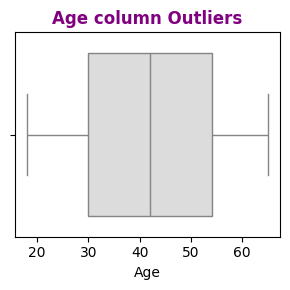

#==================================================#
Tenure Has 0 Outliers
#==================================================#


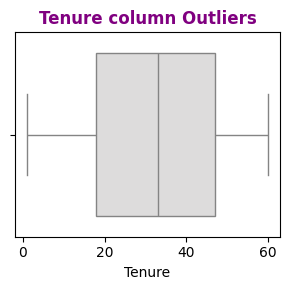

#==================================================#
Usage Frequency Has 0 Outliers
#==================================================#


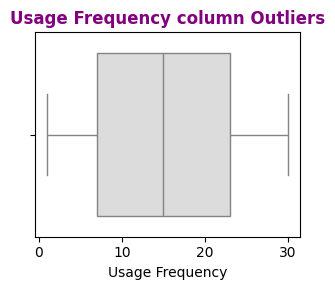

#==================================================#
Support Calls Has 0 Outliers
#==================================================#


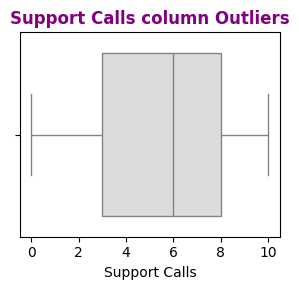

#==================================================#
Payment Delay Has 0 Outliers
#==================================================#


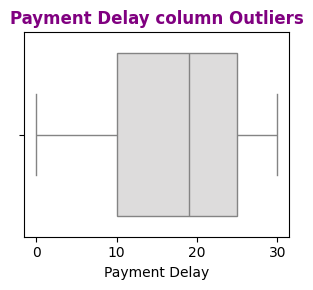

#==================================================#
Total Spend Has 0 Outliers
#==================================================#


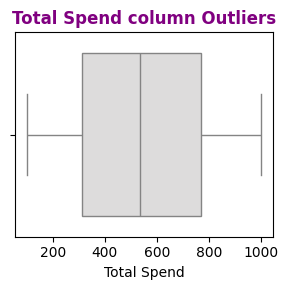

#==================================================#
Last Interaction Has 0 Outliers
#==================================================#


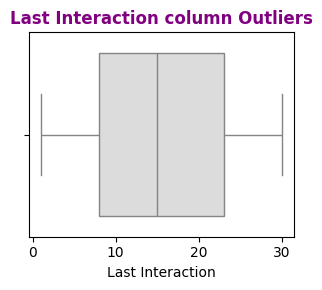

#==================================================#
Churn Has 0 Outliers
#==================================================#


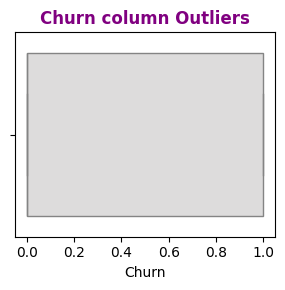

#=================================================================#
Total Dataset Percentage Outliers Present In Dataset Is: 0.00%
#=================================================================#
Total Unique Outliers Present In Dataset Is: 0
#==================================================#
✅ Outliers Detection Complete!


In [7]:
#==========================================================================================================#
# Outliers Detection
#==========================================================================================================#
outlier_data = churn_df.copy()
outlier_box = set()
numeric_columns =  outlier_data.select_dtypes(include = ['number']).columns
for num_cols in numeric_columns:
    Q1 = outlier_data[num_cols].quantile(0.25)
    Q3 = outlier_data[num_cols].quantile(0.75)
    IQR = Q3 - Q1
    Lower_round = Q1 - 1.5 * IQR
    Upper_round = Q3 + 1.5 * IQR
    outliers = outlier_data[(outlier_data[num_cols] < Lower_round) | (outlier_data[num_cols] > Upper_round)]
    outlier_box.update(outliers.index)
    print("#" + "=" * 50 + "#")
    print(f"{num_cols} Has {len(outliers)} Outliers")
    print("#" + "=" * 50 + "#")
    plt.figure(figsize = (3,3))
    plt.title(f"{num_cols} column Outliers",fontsize = 12,fontweight = 'bold',color = 'purple')
    sns.boxplot(x = outlier_data[num_cols],palette = 'coolwarm')
    plt.tight_layout()
    plt.show()

total_per = (len(outlier_box) / len(outlier_data)) * 100
print("#" + "=" * 65 + "#")
print(f"Total Dataset Percentage Outliers Present In Dataset Is: {total_per:.2f}%")
print("#" + "=" * 65 + "#")
print(f"Total Unique Outliers Present In Dataset Is: {len(outlier_box)}")
print("#" + "=" * 50 + "#")
print("✅ Outliers Detection Complete!")

#==================== Categorical Columns Distribution ====================#
#==================================================#
Gender
female    34353
male      30021
Name: count, dtype: int64


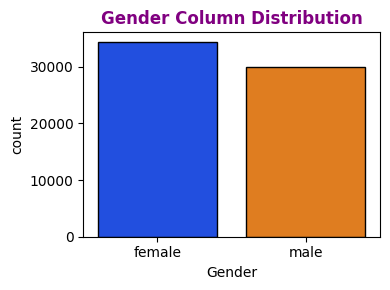

#==================================================#
Subscription Type
standard    21502
basic       21451
premium     21421
Name: count, dtype: int64


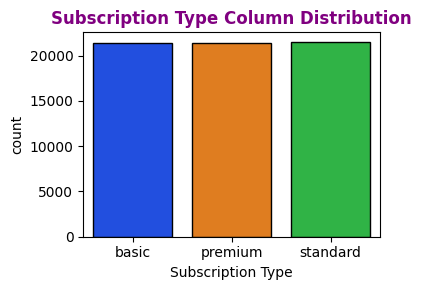

#==================================================#
Contract Length
monthly      22130
annual       21410
quarterly    20834
Name: count, dtype: int64


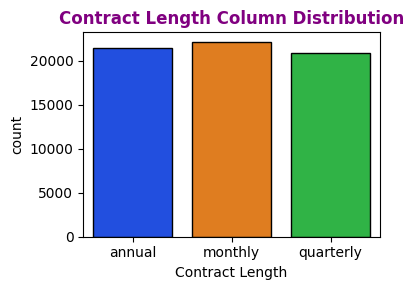


#==================== Numerical Columns Distribution ====================#
#==================================================#


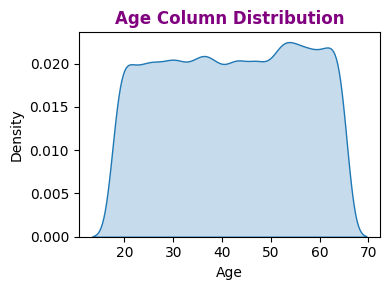

#==================================================#


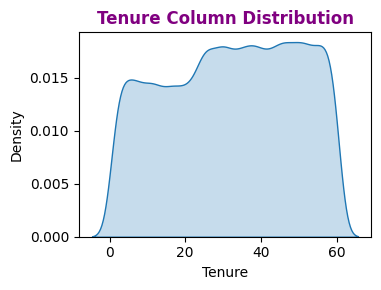

#==================================================#


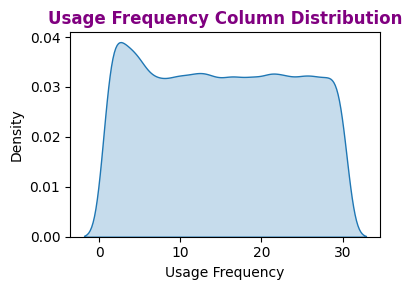

#==================================================#


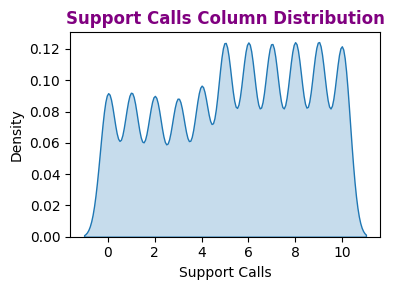

#==================================================#


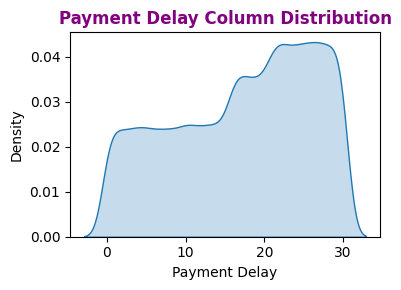

#==================================================#


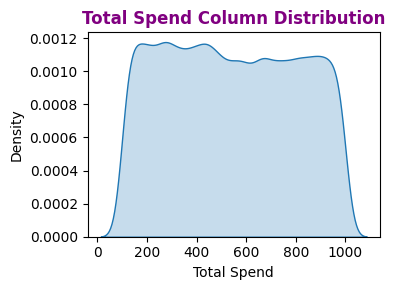

#==================================================#


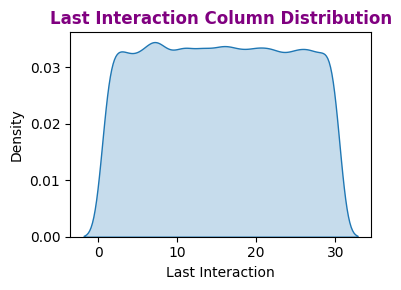

In [8]:
# Check All Categorical Columns Types 
cat_cols = churn_df.select_dtypes(include = ['category']).columns
print("#" + "=" * 20 + " Categorical Columns Distribution " + "=" * 20 + "#")
for i in cat_cols:
    print("#" + "=" * 50 + "#")
    print(churn_df[i].value_counts())
    plt.figure(figsize = (4,3))
    plt.title(f"{i} Column Distribution",fontsize = 12,fontweight = 'bold',color = 'purple')
    sns.countplot(data = churn_df,x = i,edgecolor = 'black',palette = 'bright')
    plt.tight_layout()
    plt.show()
    plt.close()

# Check All Numerical Columns Distribution 
num_cols = [c for c in churn_df.select_dtypes(include = ['number']).columns if churn_df[c].nunique() > 2]
print("\n#" + "=" * 20 + " Numerical Columns Distribution " + "=" * 20 + "#")
for num in num_cols:
    print("#" + "=" * 50 + "#")
    plt.figure(figsize = (4,3))
    plt.title(f"{num} Column Distribution",fontsize = 12,fontweight = 'bold',color = 'purple')
    sns.kdeplot(data = churn_df,x = num,fill = True)
    plt.tight_layout()
    plt.show()
    plt.close()



--- EXECUTIVE SUMMARY TABLE: AGE ---


mean            max     min    
Churn           0          1   0   1   0   1
Gender                                      
female  41.174395  42.578869  65  65  18  18
male    41.097782  43.430668  65  65  18  18

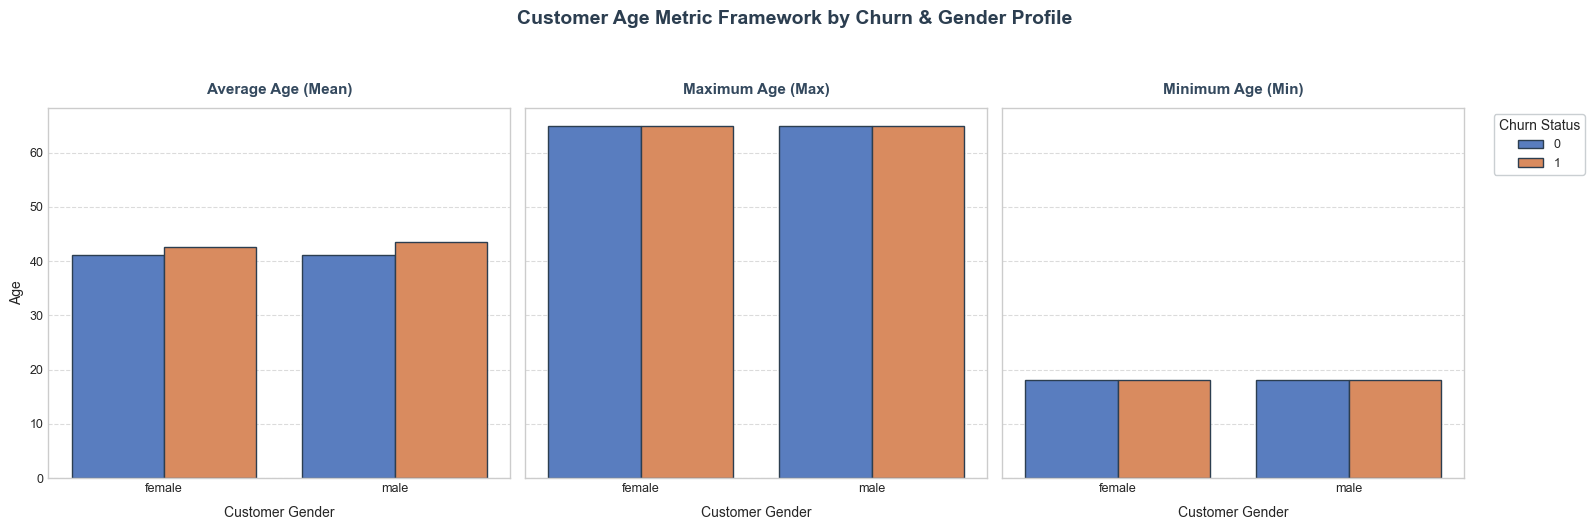


--- EXECUTIVE SUMMARY TABLE: TENURE ---


mean            max     min   
Churn           0          1   0   1   0  1
Gender                                     
female  29.262207  33.372006  60  60   1  1
male    28.461576  39.014592  60  60   1  1

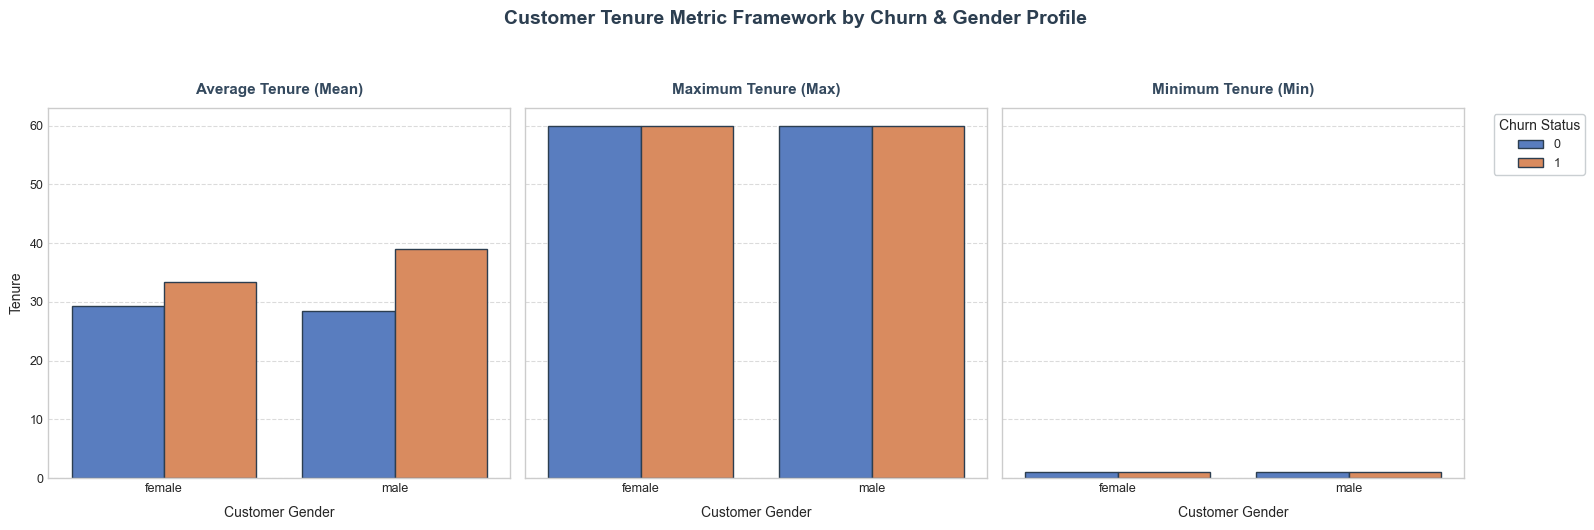


--- EXECUTIVE SUMMARY TABLE: USAGE FREQUENCY ---


mean            max     min   
Churn           0          1   0   1   0  1
Gender                                     
female  16.002914  14.430226  30  30   1  1
male    16.076414  13.325419  30  30   1  1

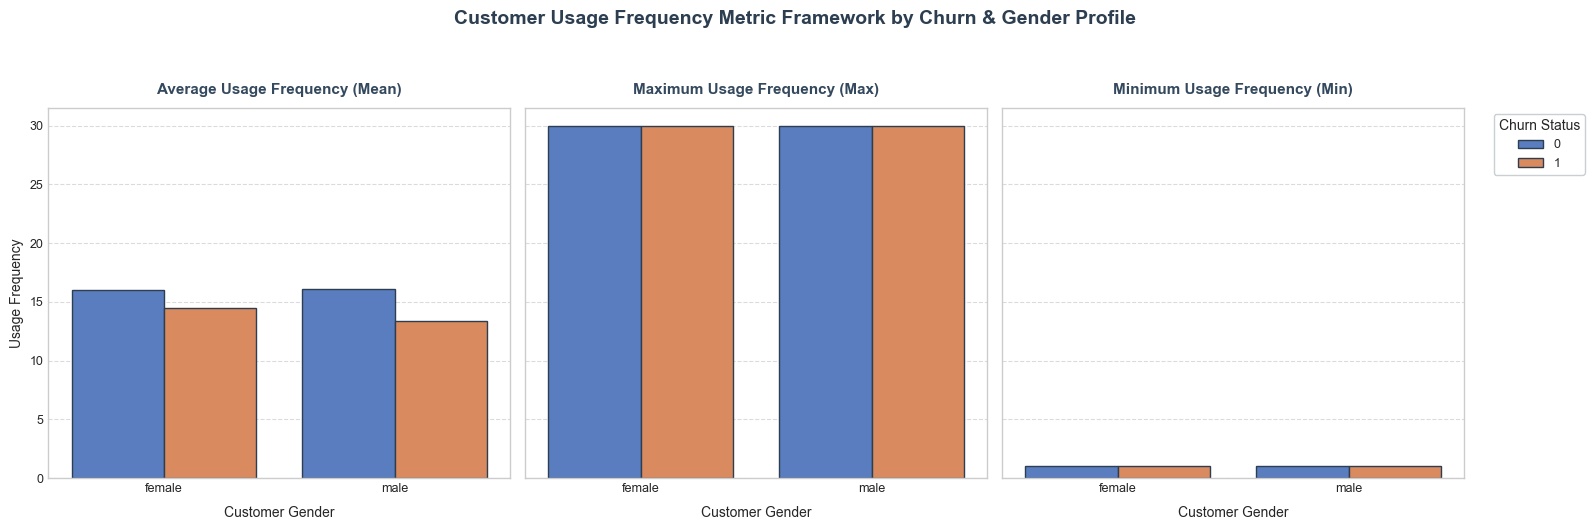


--- EXECUTIVE SUMMARY TABLE: SUPPORT CALLS ---


mean           max     min   
Churn          0         1   0   1   0  1
Gender                                   
female  4.590079  5.875311  10  10   0  0
male    4.425945  7.258332  10  10   0  0

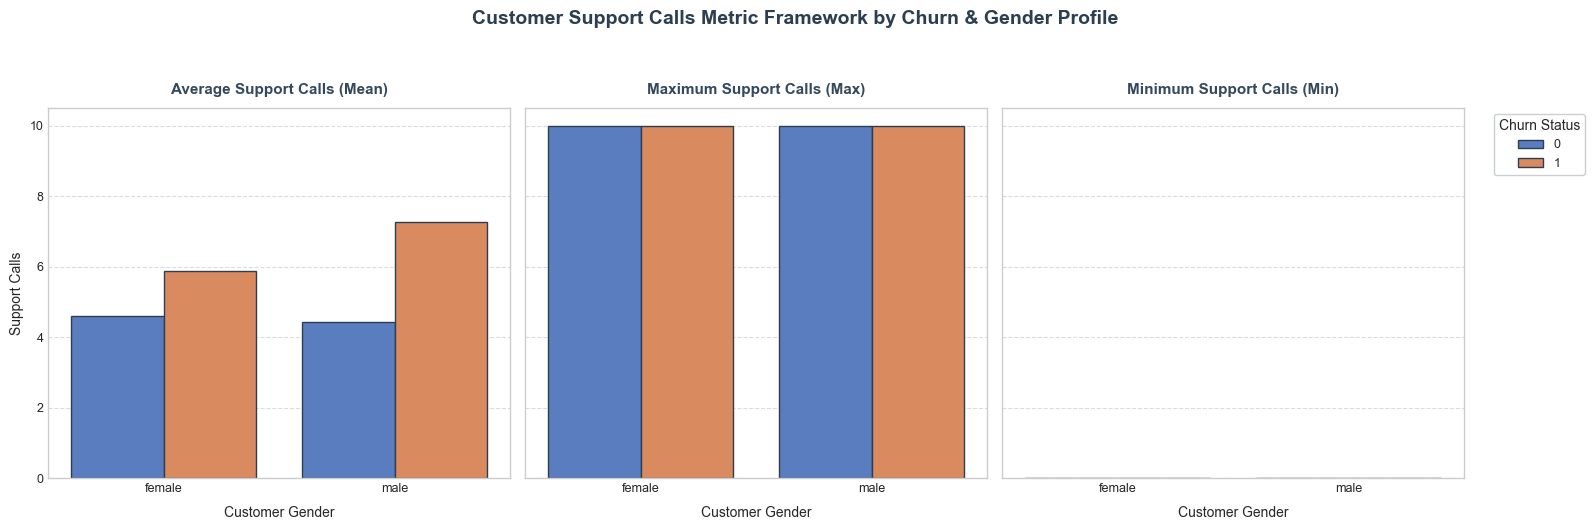


--- EXECUTIVE SUMMARY TABLE: PAYMENT DELAY ---


mean            max     min   
Churn           0          1   0   1   0  1
Gender                                     
female  11.087748  22.951615  30  30   0  0
male    13.596507  21.327923  30  30   0  0

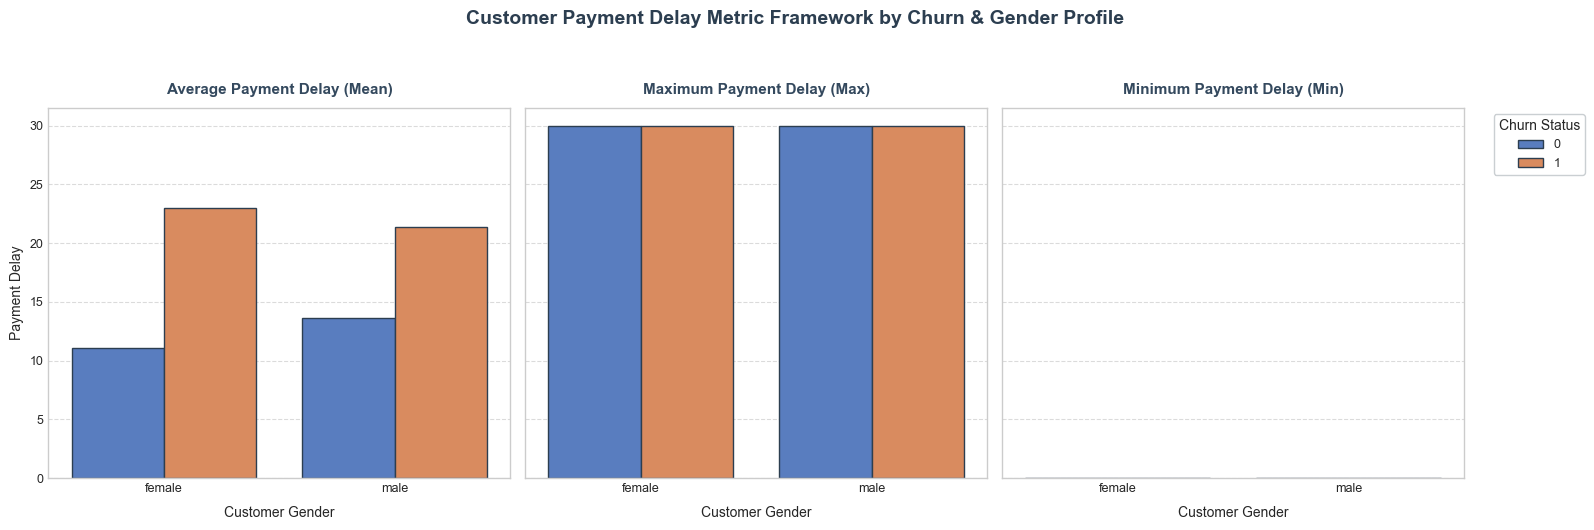


--- EXECUTIVE SUMMARY TABLE: TOTAL SPEND ---


mean               max        min     
Churn            0           1     0     1    0    1
Gender                                              
female  573.396969  501.592089  1000  1000  100  100
male    549.776344  548.308496  1000  1000  100  100

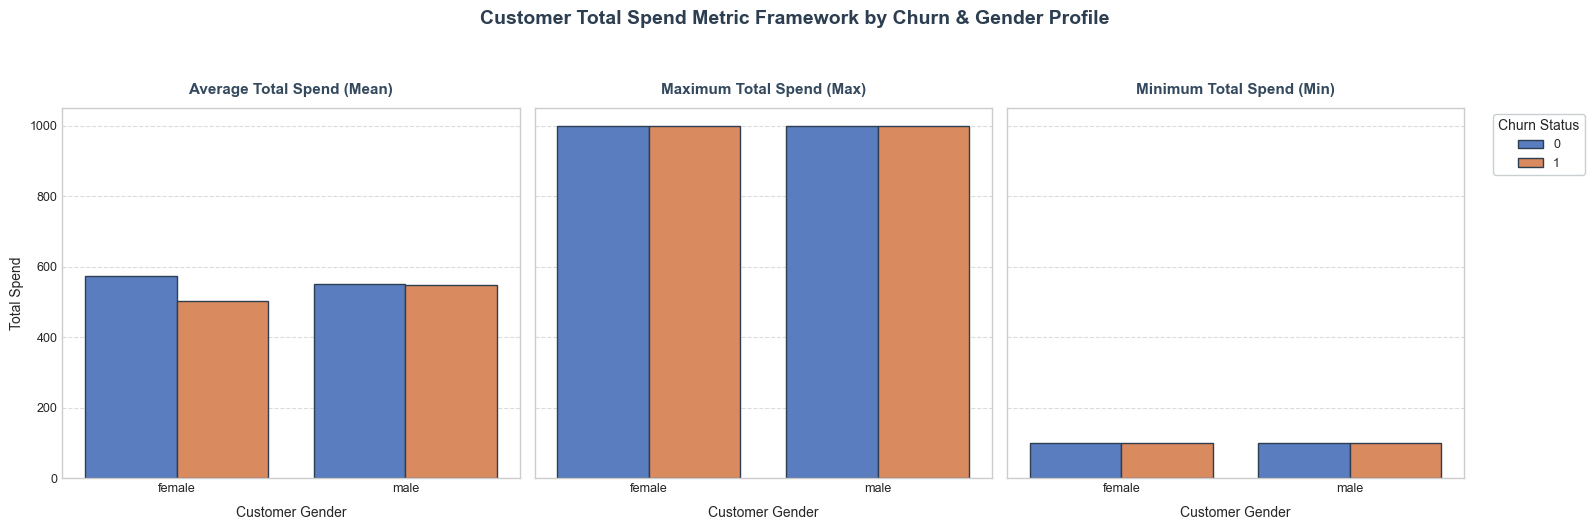


--- EXECUTIVE SUMMARY TABLE: LAST INTERACTION ---


mean            max     min   
Churn           0          1   0   1   0  1
Gender                                     
female  15.544295  15.468669  30  30   1  1
male    15.503227  15.480573  30  30   1  1

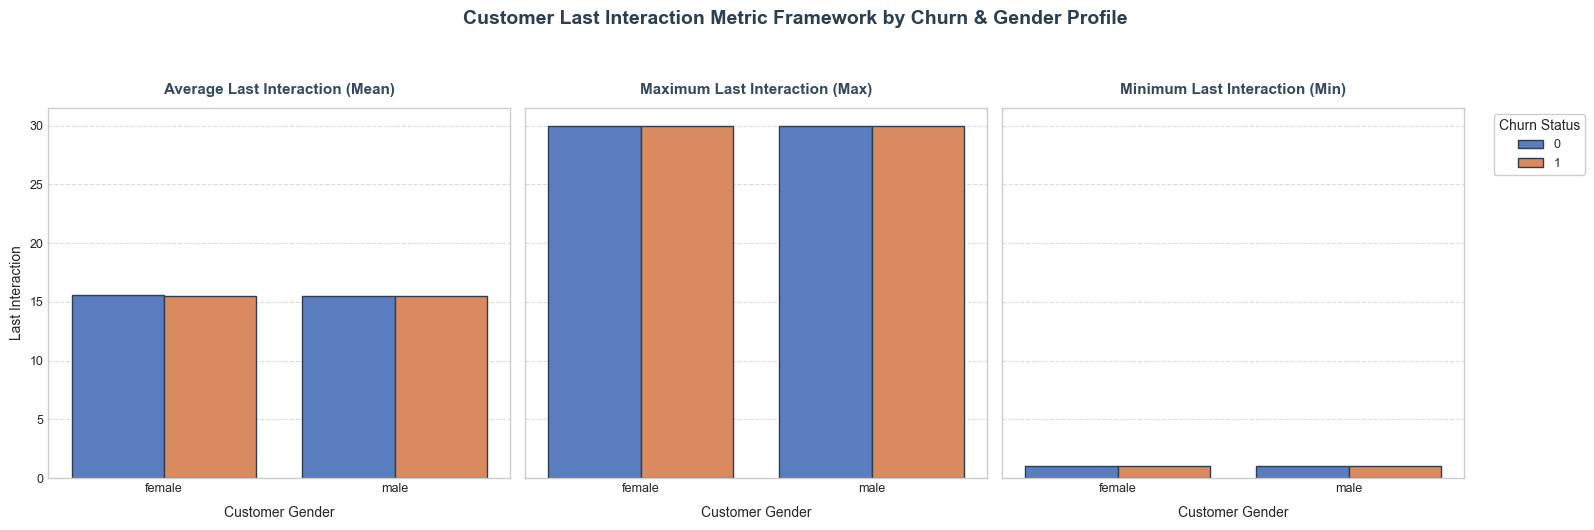

In [9]:
def generate_eda_dashboard(df, numeric_column, target_column="Churn"):
    """EDA Pipeline for Numerical Variable Analysis by Churn and Gender."""
    metrics_map = {
        "mean": f"Average {numeric_column} (Mean)",
        "max": f"Maximum {numeric_column} (Max)",
        "min": f"Minimum {numeric_column} (Min)",
    }

    summary_table = pd.pivot_table(
        df,
        index="Gender",
        columns=target_column,
        values=numeric_column,
        aggfunc=list(metrics_map.keys()),
    )
    print(f"\n--- EXECUTIVE SUMMARY TABLE: {numeric_column.upper()} ---")
    display(summary_table)

    plt.style.use("seaborn-v0_8-whitegrid")
    fig, axes = plt.subplots(
        nrows=1, ncols=3, figsize=(16, 5), sharey=True, dpi=100
    )

    fig.suptitle(
        f"Customer {numeric_column} Metric Framework by Churn & Gender Profile",
        fontsize=14,
        fontweight="bold",
        fontname="sans-serif",
        color="#2c3e50",
        y=1.05,
    )
    for idx, (metric, title) in enumerate(metrics_map.items()):
        ax = axes[idx]

        sns.barplot(
            data=df,
            x="Gender",
            y=numeric_column,
            hue=target_column,
            estimator=metric,
            errorbar=None,
            edgecolor="#2c3e50",
            linewidth=1,
            palette="muted", 
            ax=ax,
        )

        ax.set_title(title, fontsize=11, fontweight="semibold", color="#34495e", pad=10)
        ax.set_xlabel("Customer Gender", fontsize=10, labelpad=8)
        ax.set_ylabel(f"{numeric_column}" if idx == 0 else "", fontsize=10)
        ax.tick_params(labelsize=9)
        ax.grid(axis="y", linestyle="--", alpha=0.7)

        if idx == len(metrics_map) - 1:
            ax.legend(
                title=f"{target_column} Status",
                title_fontsize="10",
                fontsize="9",
                bbox_to_anchor=(1.05, 1),
                loc="upper left",
                frameon=True,
                facecolor="white",
                edgecolor="#bdc3c7",
            )
        else:
            ax.get_legend().remove()

    plt.tight_layout()
    plt.show()
    plt.close()
numeric_cols = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 
                'Payment Delay', 'Total Spend', 'Last Interaction']
for col in numeric_cols:
    generate_eda_dashboard(churn_df, numeric_column=col)

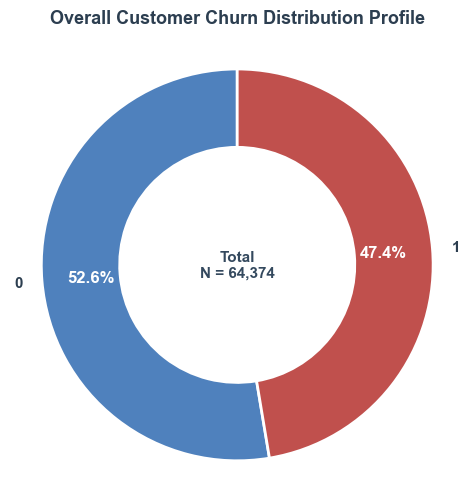

In [10]:
churn_counts = churn_df["Churn"].value_counts()
labels = churn_counts.index
sizes = churn_counts.values

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(5, 5), dpi=100)

colors = ["#4f81bd", "#c0504d"]  

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",  
    startangle=90,  
    colors=colors,
    textprops=dict(color="#2c3e50", fontsize=11, fontweight="semibold"),
    wedgeprops=dict(
        width=0.4, edgecolor="white", linewidth=2
    ),  
    pctdistance=0.75,  
)

for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(12)
    autotext.set_fontweight("bold")

total_customers = sizes.sum()
ax.text(
    0,
    0,
    f"Total\nN = {total_customers:,}",
    ha="center",
    va="center",
    fontsize=11,
    fontweight="bold",
    color="#34495e",
)
ax.set_title(
    "Overall Customer Churn Distribution Profile",
    fontsize=13,
    fontweight="bold",
    color="#2c3e50",
    pad=20,
)
ax.axis("equal")

plt.tight_layout()
plt.show()
plt.close()


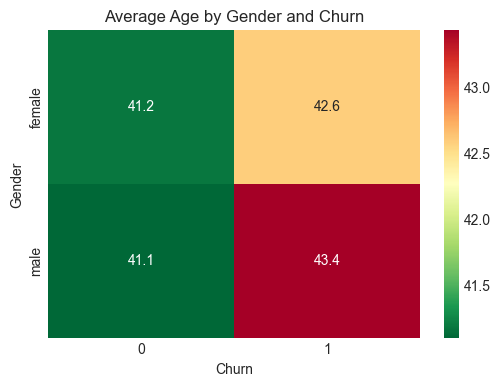

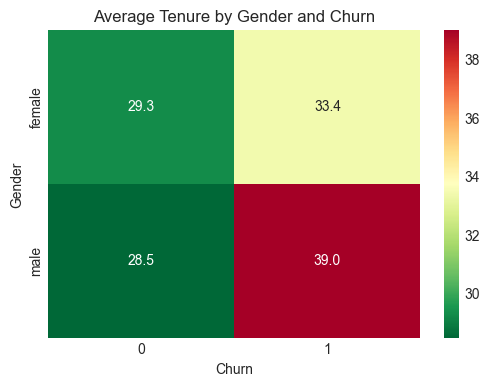

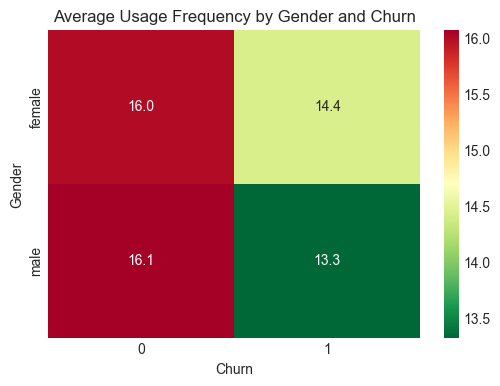

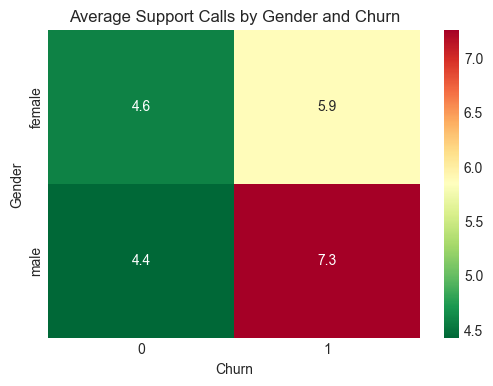

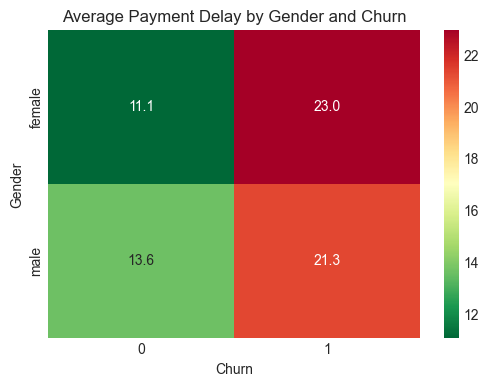

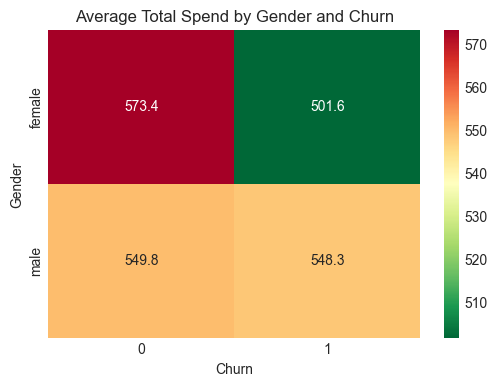

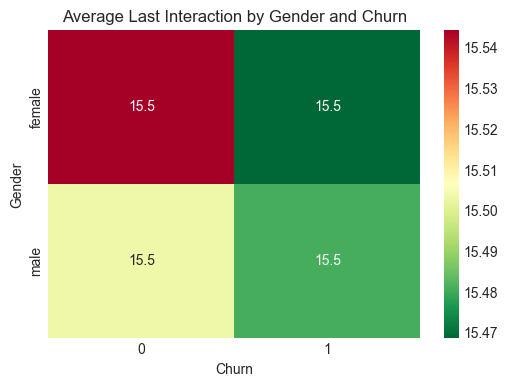

In [12]:
numeric_cols = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']
for cols in churn_df[numeric_cols]:
    c = pd.crosstab(index=churn_df['Gender'], 
                    columns=churn_df['Churn'], 
                    values=churn_df[cols], 
                    aggfunc='mean'
    )
    plt.figure(figsize=(6, 4))
    plt.title(f'Average {cols} by Gender and Churn')
    sns.heatmap(c, annot=True, cmap='RdYlGn_r', fmt='.1f')
    plt.savefig(f'heatmap_{cols.replace(" ", "_")}.png')
    plt.show()
    plt.close()

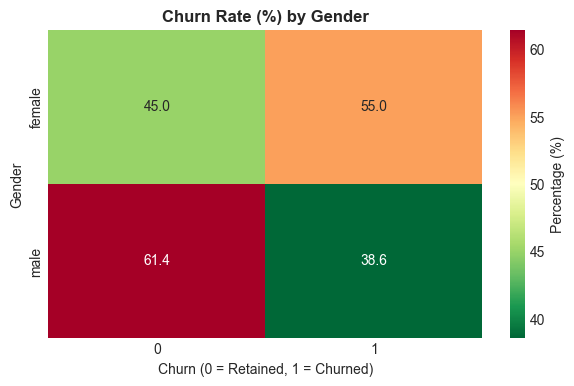

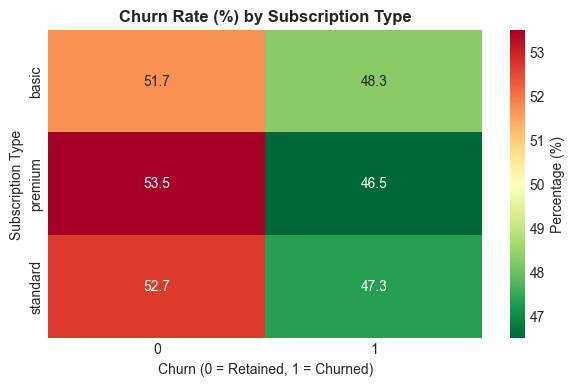

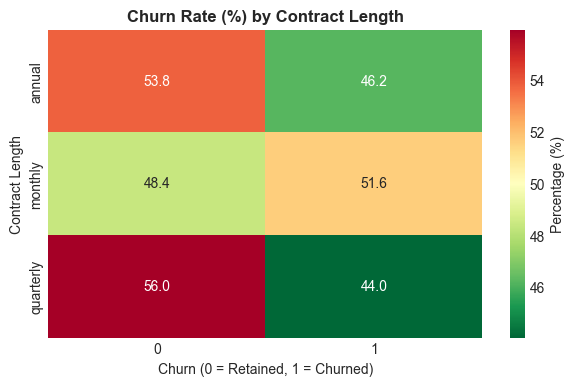

In [13]:
categorical_cols = ['Gender', 'Subscription Type', 'Contract Length']
for col in categorical_cols:
    c_percentage = pd.crosstab(churn_df[col], churn_df['Churn'], normalize='index') * 100
    plt.figure(figsize=(7, 4))
    plt.title(f'Churn Rate (%) by {col}', fontsize=12, fontweight='bold')
    sns.heatmap(c_percentage, annot=True, cmap='RdYlGn_r', fmt='.1f', cbar_kws={'label': 'Percentage (%)'})
    plt.xlabel('Churn (0 = Retained, 1 = Churned)')
    plt.ylabel(col)
    plt.savefig(f'churn_rate_{col.replace(" ", "_")}.png', bbox_inches='tight')
    plt.show()
    plt.close()

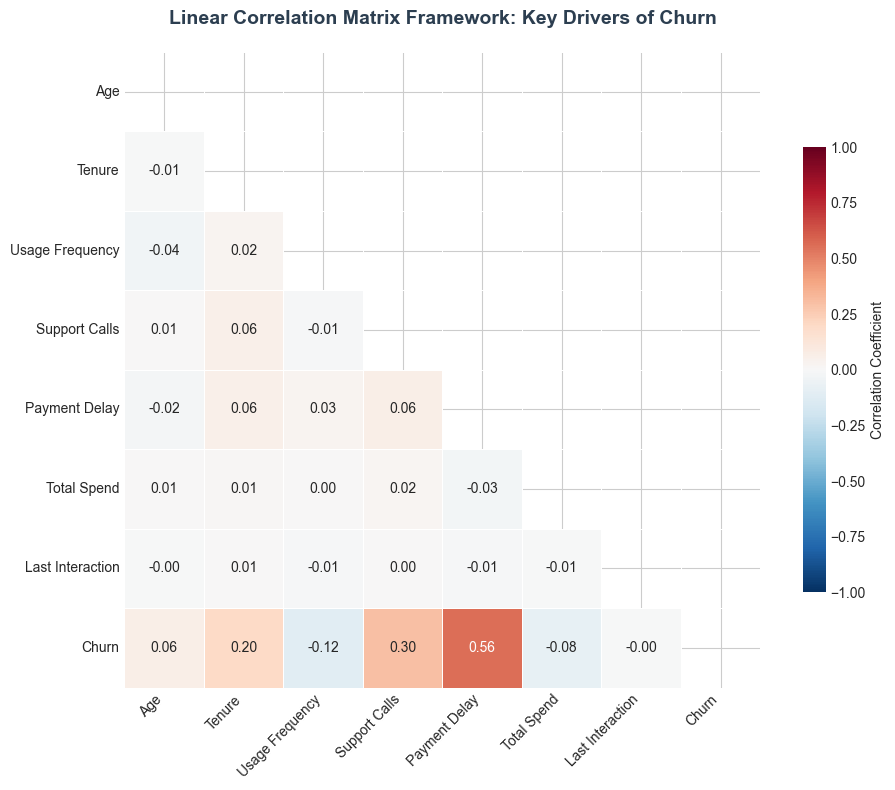

In [14]:
if churn_df["Churn"].dtype == "object" or churn_df["Churn"].dtype.name == "category":
    churn_df["Churn_Numeric"] = (
        churn_df["Churn"].astype(str).str.lower().map({"yes": 1, "true": 1, "1": 1}).fillna(0)
    )
    target_for_corr = "Churn_Numeric"
else:
    target_for_corr = "Churn"

requested_features = [
    "Age",
    "Tenure",
    "Usage Frequency",
    "Support Calls",
    "Payment Delay",
    "Total Spend",
    "Last Interaction",
    target_for_corr,
]
valid_features = [col for col in requested_features if col in churn_df.columns]

corr_matrix = churn_df[valid_features].corr()

plt.figure(figsize=(10, 8), dpi=100)
plt.style.use("seaborn-v0_8-whitegrid")

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,  
    fmt=".2f",  
    cmap="RdBu_r",  
    vmin=-1,
    vmax=1,  
    center=0,
    square=True, 
    linewidths=0.5,
    cbar_kws={
        "shrink": 0.7,
        "label": "Correlation Coefficient",
    }, 
)
plt.title(
    "Linear Correlation Matrix Framework: Key Drivers of Churn",
    fontsize=14,
    fontweight="bold",
    color="#2c3e50",
    pad=20,
)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()
plt.close()

# 📊 Final Exploratory Data Analysis (EDA) Report
## 1. High-Level Churn Disparity
* **Gender Imbalance:** A massive gender gap exists in customer retention. The churn rate for female customers stands at a staggering **55.05% (18,911 counts)**, while the male churn rate is lower at **38.58% (11,582 counts)**.
* **The Revenue Impact:** Even though churning females have a lower average total spend (**501.6**) compared to males (**548.3**) due to a shorter platform lifecycle, the sheer volume of female churn creates a massive financial threat for the business.

## 2. Demographic & Lifetime Triggers
* **Target Age Group:** Age does not skew churn across genders. The average age for both churning females (**42.6 years**) and males (**43.4 years**) sits firmly in the middle-aged bracket.
* **The Shorter Female Tenure:** Churning females abandon the service roughly 6 months earlier than males. Females average a tenure of **33.4 months** before leaving, compared to **39.0 months** for male customers, showing high risk near the 3-year milestone.

## 3. Customer Behavior & The 'Silent Churn' Risk
* **High Engagement Defect:** Interestingly, churning female customers are highly engaged with the platform before leaving, showing a higher average usage frequency (**14.4**) than their male counterparts (**13.3**).
* **The Support Gap:** Churning females average fewer support calls (**5.9**) than males (**7.3**). This highlights a dangerous **'Silent Churn' phenomenon**: active female users choose to abandon the service quietly rather than reaching out to customer support to resolve issues.

## 4. Financial & Structural Early Warnings
* **Payment Delays as a Proxy:** Churning females exhibit a longer average payment delay of **23.0 days** compared to males at **21.3 days**. Since unhappy females do not call customer support, a widening payment delay is the single best behavioral indicator of upcoming churn.
* **Subscription Plan Stability:** Lower-tier plans are most vulnerable. The **Basic** tier accounts for the highest churn (**10,356** counts), followed closely by the **Standard** tier (**10,177** counts), while the **Premium** tier shows slightly stronger loyalty (**9,960** counts).
* **The Month-to-Month Trap:** Contract structure directly controls customer retention. **Monthly Contracts** are highly volatile, triggering the highest churn volume (**11,421** counts) compared to structured commitments like **Annual** (**9,895**) and **Quarterly** (**9,177**) plans.

## 5. Feature Engineering Recommendation
* **Drop 'Last Interaction':** The average time since the Last Interaction is mathematically identical at **15.5** for both churned and retained customers. This feature carries zero predictive weight and can be safely dropped during the feature selection phase before training machine learning models.

In [15]:
churn_df['Monthly Spend'] = churn_df['Total Spend'] / churn_df['Tenure']

# **Model Building**

In [16]:
# Extract The Categorical and Numerical Features
categorical_features = ['Gender', 'Subscription Type', 'Contract Length']
numeric_features = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay','Monthly Spend']

X = churn_df[categorical_features + numeric_features]
y = churn_df['Churn']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [17]:
# Define The ColumnTransformer
preprocessing_data = ColumnTransformer(transformers=[
    ('categorical_features',OneHotEncoder(handle_unknown = 'ignore',drop = 'first'),categorical_features),
    ('numeric_features',StandardScaler(),numeric_features)
],remainder = 'passthrough')

In [18]:
models = {
    'RandomForestClassifier': RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_leaf=4,
        min_samples_split=2,
        max_features='sqrt',
        class_weight='balanced',  
        random_state=42,
        n_jobs=-1
    ),
    'GradientBoostingClassifier': GradientBoostingClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=4,
        min_samples_split=2,
        random_state=42
    ),
    'XGBClassifier': XGBClassifier(
        n_estimators=300,
        max_depth=15,
        min_child_weight=3,      
        random_state=42,
        n_jobs=-1
    ),
    'LGBMClassifier': LGBMClassifier(
        n_estimators=400,
        max_depth=20,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42,
        verbose = -1
    )
}


#============================== RandomForestClassifier ==============================#
Accuracy score Is: 0.9939

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      6793
           1       0.99      0.99      0.99      6082

    accuracy                           0.99     12875
   macro avg       0.99      0.99      0.99     12875
weighted avg       0.99      0.99      0.99     12875

Confusion Matrix:
 [[6746   47]
 [  31 6051]]
Roc-auc-score: 0.9998



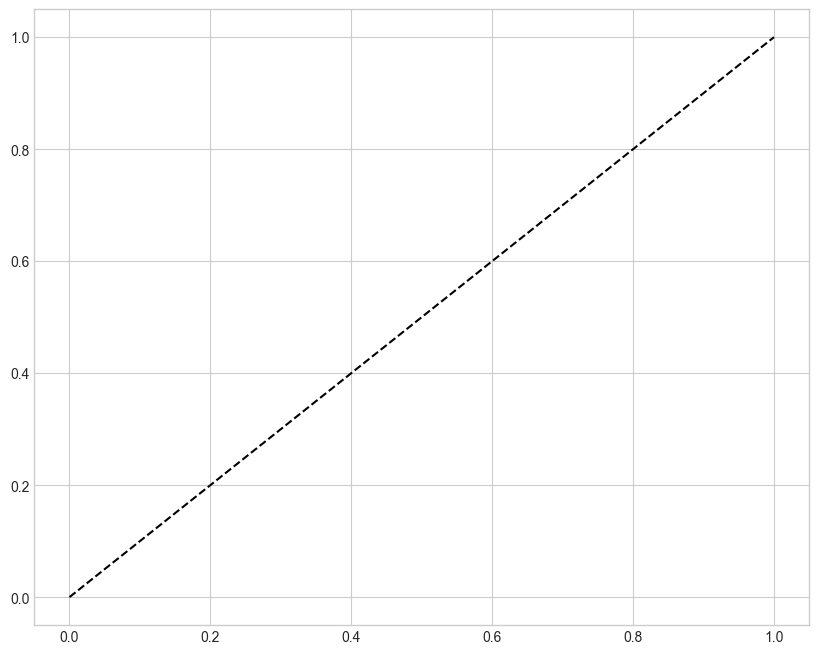

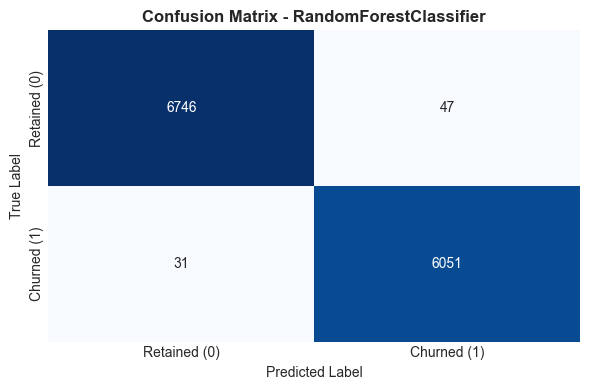

In [ ]:
plt.figure(1, figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')
for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('Preprocessing Data', preprocessing_data),
        ('Feature Selection', SelectKBest(score_func=f_classif, k='all')),
        (name, model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

    print("#" + "=" * 30 + f" {name} " + "=" * 30 + "#")
    print(f"Accuracy score Is: {accuracy_score(y_test, y_pred):.4f}") 
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print(f"Roc-auc-score: {roc_auc_score(y_test, y_pred_proba):.4f}\n")
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Retained (0)', 'Churned (1)'],
                yticklabels=['Retained (0)', 'Churned (1)'])
    
    plt.title(f'Confusion Matrix - {name}', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.savefig(f'heatmap_{name}.png', dpi=300)
    plt.show()
    plt.close() 
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(1)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', linewidth=2)
plt.figure(1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Recall)', fontsize=11)
plt.title('ROC-AUC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('combined_roc_auc_curve.png', dpi=300)
plt.show()

In [ ]:
final_pipeline = Pipeline(steps=[
    ('Preprocessing Data', preprocessing_data),
    ('Feature Selection', SelectKBest(score_func=f_classif, k='all')),
    ('LightGBM', LGBMClassifier(
        n_estimators=400,
        max_depth=20,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    ))
])
final_pipeline.fit(X_train, y_train)
scores = cross_val_score(final_pipeline, X, y, scoring='f1', cv=5)
print("#" + "=" * 20 + " Cross-Validation Results " + "=" * 20 + "#")
print(f"F1-Scores for each fold: {np.round(scores, 4)}")
print(f"Mean F1-Score: {scores.mean():.4f}")
print(f"F1-Score Standard Deviation: {scores.std():.4f}")
joblib.dump(final_pipeline, 'final_churn_model_lightgbm.pkl')
print("🏆 Final LightGBM Model Pipeline Saved Successfully as 'final_churn_model_lightgbm.pkl!")

### 📊 Machine Learning Models Performance Summary

The table below summarizes the performance metrics of all tested ensemble and boosting models on the customer churn test dataset (12,875 records). 

| Model Name | Accuracy | ROC-AUC Score | Cross-Validation F1-Mean | Confusion Matrix (TN / FP / FN / TP) | Total Misclassifications | Model Verdict |
| :--- | :---: | :---: | :---: | :---: | :---: | :--- |
| **LightGBM (LGBMClassifier)** | **99.92%** | **1.0000** | **99.87% (±0.0004)** | `[[6785, 8], [2, 6080]]` | **10** | 🏆 **Winner:** Best overall accuracy, highest stability, and near-perfect recall. |
| **XGBoost (XGBClassifier)** | 99.82% | 1.0000 | N/A | `[[6779, 14], [9, 6073]]` | 23 | **Highly Competitive:** Extremely fast training with minor misclassifications. |
| **Gradient Boosting (GBM)** | 99.74% | 1.0000 | N/A | `[[6771, 22], [12, 6070]]` | 34 | **Good Performance:** Highly accurate but slowest execution time due to single-threading. |
| **Random Forest Classifier** | 99.39% | 0.9998 | N/A | `[[6746, 47], [31, 6051]]` | 78 | **Baseline Ensemble:** High performance but slightly lower recall compared to boosting trees. |

*Note: TN = True Negatives, FP = False Positives, FN = False Negatives, TP = True Positives.*